In [1]:
# Impor semua library yang diperlukan di awal notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from matplotlib.colors import ListedColormap

# Pengaturan tampilan grafik
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print("Semua library berhasil diimpor.")

Semua library berhasil diimpor.


Pernahkah Anda memperhatikan bagaimana media sosial seolah mampu merekomendasikan konten yang sesuai dengan minat Anda? Atau ketika berbelanja di toko online, rekomendasi produk yang muncul sering kali terasa relevan dengan kebutuhan Anda saat itu? Kemampuan sistem untuk “menebak” preferensi pengguna ini bukanlah kebetulan. Artikel ini membahas konsep dasar yang banyak digunakan di balik mekanisme tersebut, yaitu machine learning.

## 1. Definisi Machine Learning

### 1.1 Apa itu Machine Learning?

*Machine learning* (ML) adalah cabang kecerdasan buatan (*artificial intelligence*/AI) yang memungkinkan komputer untuk **belajar dari data** tanpa diprogram secara eksplisit untuk setiap tugas yang diberikan. Analoginya seperti mengajarkan seorang anak tentang hal-hal baru. Bayangkan Anda ingin mengajarkan seorang anak cara membedakan kucing dan anjing. Anda tidak mendefinisikan aturan seperti *"jika berkumis panjang dan bertelinga runcing, maka kucing"*. Sebaliknya, Anda menunjukkan ratusan foto kucing dan anjing, dan anak tersebut secara bertahap **menemukan sendiri** pola yang membedakan keduanya. Inilah yang dilakukan *machine learning*. Komputer **menemukan pola** dari data secara otomatis.

Terdapat beberapa komponen Utama dalam Sistem *Machine Learning*:

| Komponen | Penjelasan | Contoh |
|----------|-----------|--------|
| **Data** | Kumpulan informasi yang digunakan untuk belajar | Tabel pasien, foto, rekaman sensor |
| **Fitur (X)** | Variabel input yang mendeskripsikan setiap observasi | Tinggi badan, suhu, kata dalam teks |
| **Label (y)** | Variabel output yang ingin diprediksi | Diagnosis, harga, kategori |
| **Model** | Fungsi matematis yang memetakan X ke y | Persamaan linear, pohon keputusan |
| **Algoritma** | Prosedur untuk menemukan model terbaik dari data | Gradient descent, K-NN |

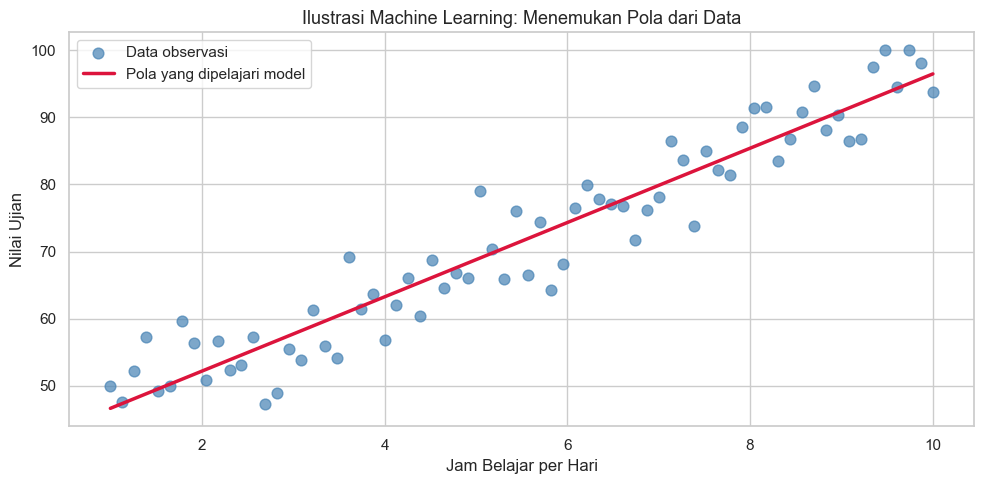

Persamaan yang ditemukan model: Nilai = 5.54 * JamBelajar + 41.10
Artinya: setiap tambahan 1 jam belajar, nilai diprediksi naik sekitar 5.54 poin.


In [2]:
# Ilustrasi: pola yang 'dipelajari' oleh model dari data
# Kasus sederhana: hubungan antara jam belajar dan nilai ujian

np.random.seed(42)
jam_belajar = np.linspace(1, 10, 70)
nilai_ujian  = 42 + 5.5 * jam_belajar + np.random.normal(0, 5, 70)
nilai_ujian  = np.clip(nilai_ujian, 0, 100)

# Model menemukan persamaan garis terbaik secara otomatis
koef = np.polyfit(jam_belajar, nilai_ujian, 1)
garis_pred = np.poly1d(koef)

plt.figure(figsize=(10, 5))
plt.scatter(jam_belajar, nilai_ujian,
            color='steelblue', alpha=0.7, s=60, label='Data observasi')
plt.plot(jam_belajar, garis_pred(jam_belajar),
         color='crimson', linewidth=2.5, label='Pola yang dipelajari model')
plt.xlabel('Jam Belajar per Hari', fontsize=12)
plt.ylabel('Nilai Ujian', fontsize=12)
plt.title('Ilustrasi Machine Learning: Menemukan Pola dari Data', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Persamaan yang ditemukan model: Nilai = {koef[0]:.2f} * JamBelajar + {koef[1]:.2f}")
print(f"Artinya: setiap tambahan 1 jam belajar, nilai diprediksi naik sekitar {koef[0]:.2f} poin.")

---

## 9.2 Perbedaan Machine Learning dengan Pemrograman Konvensional

### Dua Paradigma yang Berlawanan

Pemrograman konvensional dan *machine learning* bekerja dengan alur yang berlawanan:

**Pemrograman Konvensional:**
```
Data + Aturan (dibuat manual) --> Program --> Output
```

**Machine Learning:**
```
Data + Output (label/jawaban) --> Algoritma ML --> Model (aturan otomatis)
```

Pada pemrograman konvensional, *programmer* harus merumuskan setiap aturan secara eksplisit. Pada ML, algoritma yang merumuskan aturan tersebut sendiri berdasarkan data.

### Perbandingan Mendetail

| Aspek | Pemrograman Konvensional | Machine Learning |
|-------|--------------------------|-----------------|
| **Pembuat aturan** | Programmer secara manual | Algoritma secara otomatis |
| **Sumber pengetahuan** | Keahlian domain manusia | Data historis berlabel |
| **Kemampuan adaptasi** | Statis, harus diubah manual | Dapat diperbarui dengan data baru |
| **Skala** | Sulit untuk masalah berdimensi tinggi | Skalabel dengan jumlah data |
| **Cocok untuk** | Logika bisnis yang jelas dan pasti | Pola kompleks yang sulit dirumuskan |
| **Contoh** | Kalkulator, validasi formulir | Pendeteksi wajah, rekomendasi konten |

### Kapan Memilih Masing-masing?

Pemrograman konvensional masih menjadi pilihan terbaik untuk tugas-tugas dengan logika yang terdefinisi dengan baik, seperti menghitung pajak atau memvalidasi format email. ML lebih unggul ketika aturan sulit dirumuskan secara eksplisit, seperti mengenali emosi dalam teks atau mendeteksi anomali pada gambar medis.

In [3]:
# Pendekatan 1: Pemrograman Konvensional
# Aturan klasifikasi spesies bunga dibuat MANUAL oleh programmer

def klasifikasi_konvensional(panjang_petal, lebar_petal):
    """
    Aturan dibuat secara manual berdasarkan pengetahuan domain.
    Kekurangan: rapuh dan sulit mencakup semua kasus tepi.
    """
    if panjang_petal < 2.5:
        return "Setosa"
    elif panjang_petal < 4.9 and lebar_petal < 1.6:
        return "Versicolor"
    elif panjang_petal >= 4.9 and lebar_petal >= 1.6:
        return "Virginica"
    else:
        return "Tidak diketahui"   # aturan tidak mencakup semua kasus!

print("=== Pendekatan Konvensional: Aturan Dibuat Manual ===")
contoh_data = [(1.4, 0.2), (4.5, 1.4), (5.6, 2.2), (4.8, 1.5)]
for p, l in contoh_data:
    hasil = klasifikasi_konvensional(p, l)
    print(f"  Panjang petal = {p}, Lebar petal = {l}  -->  {hasil}")

print()
print("Keterbatasan: aturan harus dibuat satu per satu.")
print("Bayangkan jika ada 10 fitur dan 50 kelas -- tidak praktis!")

=== Pendekatan Konvensional: Aturan Dibuat Manual ===
  Panjang petal = 1.4, Lebar petal = 0.2  -->  Setosa
  Panjang petal = 4.5, Lebar petal = 1.4  -->  Versicolor
  Panjang petal = 5.6, Lebar petal = 2.2  -->  Virginica
  Panjang petal = 4.8, Lebar petal = 1.5  -->  Versicolor

Keterbatasan: aturan harus dibuat satu per satu.
Bayangkan jika ada 10 fitur dan 50 kelas -- tidak praktis!


In [4]:
# Pendekatan 2: Machine Learning
# Model BELAJAR sendiri pola klasifikasi dari data -- tanpa aturan manual

iris = load_iris()
X = iris.data[:, 2:4]   # panjang dan lebar petal
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Proses belajar terjadi di satu baris ini
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

print("=== Pendekatan Machine Learning: Aturan Dipelajari dari Data ===")
nama_kelas = iris.target_names
for p, l in contoh_data:
    idx = model_knn.predict([[p, l]])[0]
    print(f"  Panjang petal = {p}, Lebar petal = {l}  -->  {nama_kelas[idx]}")

akurasi = accuracy_score(y_test, model_knn.predict(X_test))
print()
print(f"Akurasi model pada data uji : {akurasi:.2%}")
print(f"Model dilatih dari          : {len(X_train)} data contoh")
print("Tidak ada satu pun aturan yang ditulis manual oleh programmer.")

=== Pendekatan Machine Learning: Aturan Dipelajari dari Data ===
  Panjang petal = 1.4, Lebar petal = 0.2  -->  setosa
  Panjang petal = 4.5, Lebar petal = 1.4  -->  versicolor
  Panjang petal = 5.6, Lebar petal = 2.2  -->  virginica
  Panjang petal = 4.8, Lebar petal = 1.5  -->  versicolor

Akurasi model pada data uji : 100.00%
Model dilatih dari          : 105 data contoh
Tidak ada satu pun aturan yang ditulis manual oleh programmer.


---

## 9.3 Mengapa Machine Learning Dibutuhkan dalam Sains Data?

### Tantangan Data Modern

Dalam era digital, volume dan kompleksitas data telah melampaui kemampuan manusia untuk memproses dan mengekstrak pola secara manual. Berikut adalah alasan-alasan utama mengapa ML menjadi kebutuhan mendasar:

**1. Volume Data yang Masif**  
Setiap hari, miliaran transaksi, pesan, gambar, dan rekaman sensor dihasilkan di seluruh dunia. Tidak mungkin manusia memeriksa dan membuat aturan untuk setiap skenario yang ada.

**2. Kompleksitas Pola**  
Banyak pola dalam data terlalu rumit untuk dirumuskan sebagai aturan eksplisit. Bagaimana Anda menuliskan aturan untuk mendeteksi sel kanker dari ribuan piksel gambar MRI?

**3. Kebutuhan Adaptasi**  
Data dan perilaku pengguna terus berubah. Model ML dapat diperbarui secara periodik dengan data terbaru tanpa harus menulis ulang seluruh program.

**4. Personalisasi Skala Besar**  
Platform seperti Spotify atau Netflix melayani ratusan juta pengguna dengan preferensi berbeda-beda. Tidak ada cara lain untuk melakukan personalisasi ini selain dengan ML.

**5. Penemuan Pengetahuan Baru**  
ML dapat mengungkap pola yang tidak pernah terpikirkan oleh manusia, misalnya hubungan antar-gen dalam bioinformatika atau sinyal penipuan keuangan yang sangat halus.

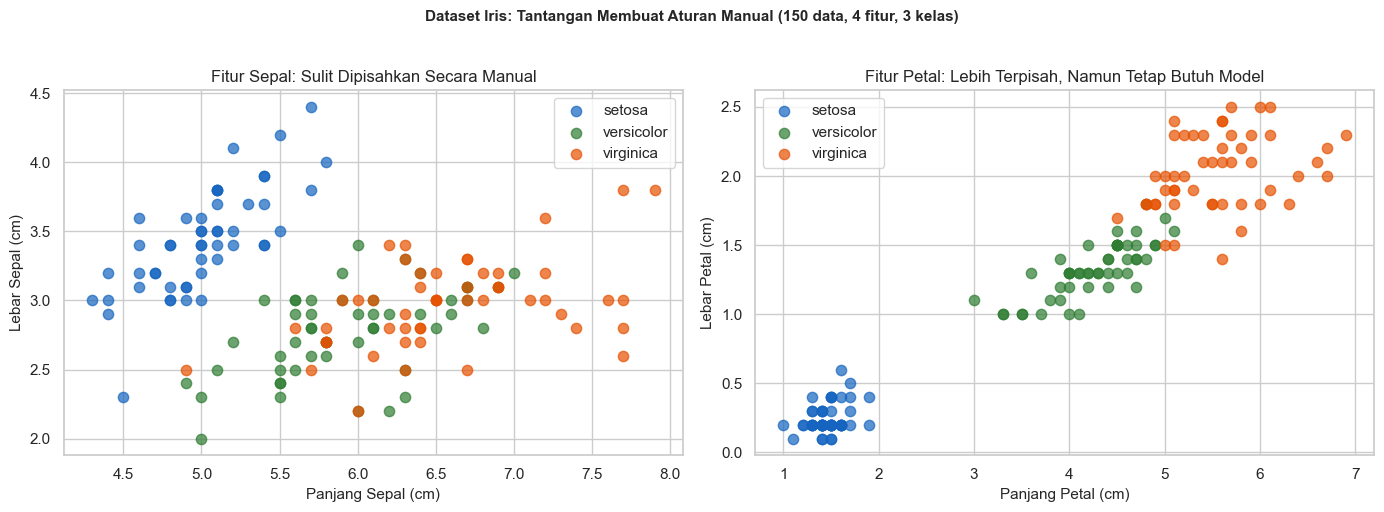

Dengan 4 fitur dan 3 kelas, membuat aturan pemisahan manual yang tepat sangatlah sulit.
ML memecahkan masalah ini secara otomatis dengan belajar dari contoh data.


In [5]:
# Visualisasi: mengapa aturan manual sulit pada data nyata

iris = load_iris()
df = pd.DataFrame(iris.data,
                  columns=['Panjang Sepal', 'Lebar Sepal', 'Panjang Petal', 'Lebar Petal'])
df['Spesies'] = [iris.target_names[i] for i in iris.target]

warna = {'setosa': '#1565C0', 'versicolor': '#2E7D32', 'virginica': '#E65100'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot kiri: fitur sepal (tumpang tindih, sulit dipisahkan manual)
for sp, grp in df.groupby('Spesies'):
    axes[0].scatter(grp['Panjang Sepal'], grp['Lebar Sepal'],
                    label=sp, color=warna[sp], alpha=0.7, s=55)
axes[0].set_xlabel('Panjang Sepal (cm)', fontsize=11)
axes[0].set_ylabel('Lebar Sepal (cm)', fontsize=11)
axes[0].set_title('Fitur Sepal: Sulit Dipisahkan Secara Manual', fontsize=12)
axes[0].legend()

# Plot kanan: fitur petal (lebih terpisah, namun tetap membutuhkan model)
for sp, grp in df.groupby('Spesies'):
    axes[1].scatter(grp['Panjang Petal'], grp['Lebar Petal'],
                    label=sp, color=warna[sp], alpha=0.7, s=55)
axes[1].set_xlabel('Panjang Petal (cm)', fontsize=11)
axes[1].set_ylabel('Lebar Petal (cm)', fontsize=11)
axes[1].set_title('Fitur Petal: Lebih Terpisah, Namun Tetap Butuh Model', fontsize=12)
axes[1].legend()

plt.suptitle('Dataset Iris: Tantangan Membuat Aturan Manual (150 data, 4 fitur, 3 kelas)',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Dengan 4 fitur dan 3 kelas, membuat aturan pemisahan manual yang tepat sangatlah sulit.")
print("ML memecahkan masalah ini secara otomatis dengan belajar dari contoh data.")

---

## Tambahan: Anatomi Dataset dalam Machine Learning

Sebelum membahas jenis-jenis ML, penting untuk memahami struktur data yang digunakan. Pemahaman tentang fitur, label, dan struktur dataset adalah fondasi dari seluruh proses ML.

### Terminologi Penting

| Istilah | Simbol | Penjelasan |
|---------|--------|-----------|
| **Dataset** | D | Kumpulan seluruh data yang tersedia |
| **Sampel / Observasi** | n | Satu baris data (satu contoh) |
| **Fitur / Atribut** | X | Kolom input yang mendeskripsikan setiap observasi |
| **Label / Target** | y | Kolom output yang ingin diprediksi |
| **Dimensi** | d | Jumlah fitur dalam dataset |

### Analogi Spreadsheet

Bayangkan sebuah tabel data mahasiswa:
- Setiap **baris** = satu mahasiswa (satu sampel)
- Kolom `IPK`, `Kehadiran (%)`, `Jam Belajar/hari` = **fitur (X)**
- Kolom `Lulus Tepat Waktu` (Ya/Tidak) = **label (y)**

Model ML belajar untuk memetakan X ke y berdasarkan contoh-contoh yang diberikan.

In [6]:
# Eksplorasi struktur dataset: memahami fitur vs label

iris = load_iris()
X = iris.data
y = iris.target

print("=== Struktur Dataset Iris ===")
print(f"Jumlah sampel (n)  : {X.shape[0]} baris")
print(f"Jumlah fitur (d)   : {X.shape[1]} kolom")
print(f"Nama fitur         : {list(iris.feature_names)}")
print(f"Kelas yang ada     : {list(iris.target_names)}")
print(f"Distribusi kelas   : {dict(zip(iris.target_names, np.bincount(y)))}")

# Tampilkan sebagai DataFrame
df = pd.DataFrame(X, columns=['Panjang Sepal', 'Lebar Sepal', 'Panjang Petal', 'Lebar Petal'])
df['Label (Spesies)'] = [iris.target_names[i] for i in y]

print("\n10 baris pertama dataset:")
print(df.head(10).to_string(index=True))

=== Struktur Dataset Iris ===
Jumlah sampel (n)  : 150 baris
Jumlah fitur (d)   : 4 kolom
Nama fitur         : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Kelas yang ada     : ['setosa', 'versicolor', 'virginica']
Distribusi kelas   : {'setosa': 50, 'versicolor': 50, 'virginica': 50}

10 baris pertama dataset:
   Panjang Sepal  Lebar Sepal  Panjang Petal  Lebar Petal Label (Spesies)
0            5.1          3.5            1.4          0.2          setosa
1            4.9          3.0            1.4          0.2          setosa
2            4.7          3.2            1.3          0.2          setosa
3            4.6          3.1            1.5          0.2          setosa
4            5.0          3.6            1.4          0.2          setosa
5            5.4          3.9            1.7          0.4          setosa
6            4.6          3.4            1.4          0.3          setosa
7            5.0          3.4            1.5          0.2

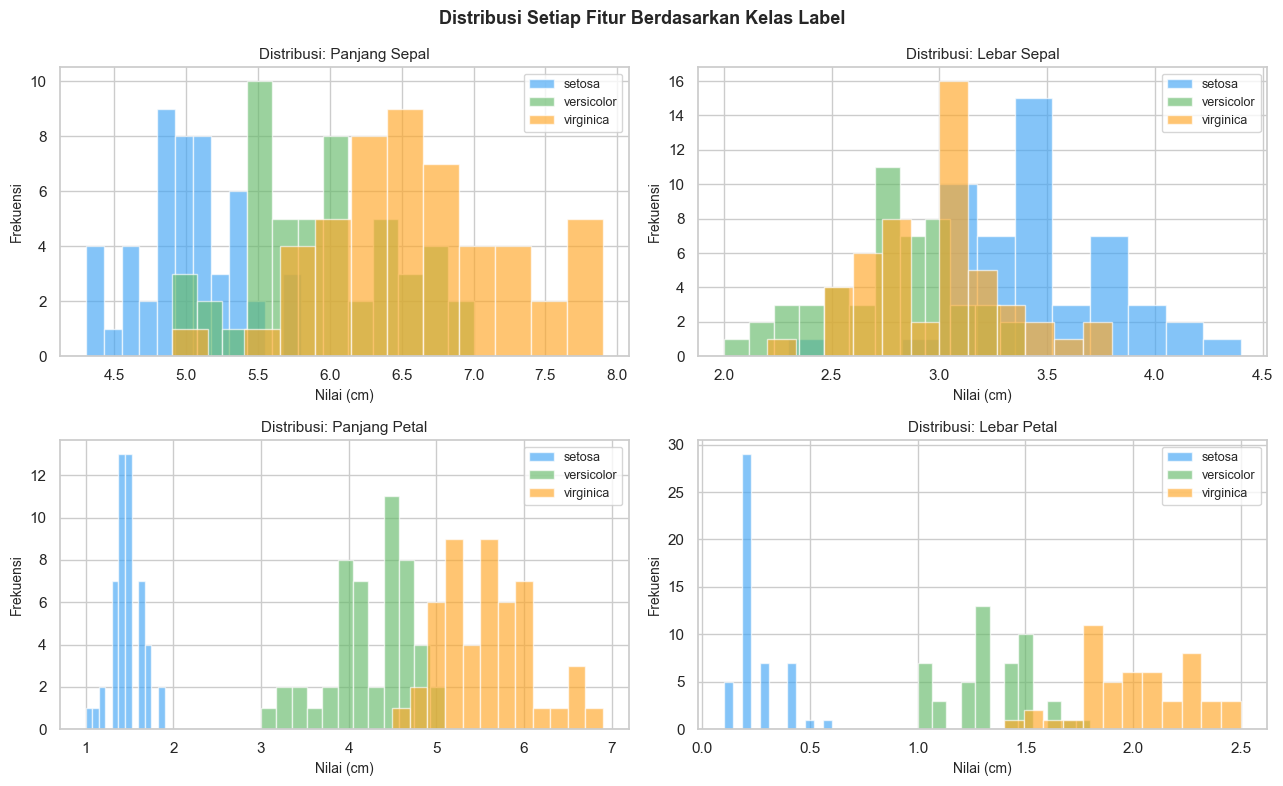

Perhatikan bahwa fitur Panjang dan Lebar Petal memiliki pemisahan kelas yang lebih jelas.
Fitur-fitur dengan pemisahan baik sangat berguna bagi model ML untuk membuat prediksi.


In [7]:
# Visualisasi distribusi setiap fitur berdasarkan kelas label

df = pd.DataFrame(iris.data, columns=['Panjang Sepal','Lebar Sepal','Panjang Petal','Lebar Petal'])
df['Spesies'] = [iris.target_names[i] for i in iris.target]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
warna_hist = ['#42A5F5', '#66BB6A', '#FFA726']

for i, fitur in enumerate(['Panjang Sepal', 'Lebar Sepal', 'Panjang Petal', 'Lebar Petal']):
    for j, spesies in enumerate(iris.target_names):
        data_sp = df[df['Spesies'] == spesies][fitur]
        axes[i].hist(data_sp, bins=12, alpha=0.65, label=spesies, color=warna_hist[j])
    axes[i].set_title(f'Distribusi: {fitur}', fontsize=11)
    axes[i].set_xlabel('Nilai (cm)', fontsize=10)
    axes[i].set_ylabel('Frekuensi', fontsize=10)
    axes[i].legend(fontsize=9)

plt.suptitle('Distribusi Setiap Fitur Berdasarkan Kelas Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Perhatikan bahwa fitur Panjang dan Lebar Petal memiliki pemisahan kelas yang lebih jelas.")
print("Fitur-fitur dengan pemisahan baik sangat berguna bagi model ML untuk membuat prediksi.")

---

## 9.4 Supervised Learning

### Definisi

*Supervised learning* (pembelajaran terawasi) adalah paradigma ML di mana model dilatih menggunakan **data berlabel**: setiap contoh input X sudah memiliki jawaban benar y yang diketahui.

Disebut "terawasi" karena proses pelatihan menyerupai seorang guru (*supervisor*) yang memberikan jawaban benar kepada siswa (model) agar model dapat belajar dari koreksi tersebut.

### Alur Umum Supervised Learning

```
[Data Berlabel: (X, y)] --> [Algoritma ML] --> [Model Terlatih]
                                                      |
                   [Data Baru: X_baru] -------------> [Prediksi: y_baru]
```

### Dua Kategori Utama

Berdasarkan jenis label (y), *supervised learning* dibagi menjadi:

| Kategori | Label (y) | Contoh Output |
|----------|-----------|--------------|
| **Klasifikasi** | Kategori diskrit (kelas) | "Spam", "Bukan Spam" |
| **Regresi** | Nilai kontinu (angka real) | 350.5, 28.7, 92.1 |

### 9.4.1 Klasifikasi

**Klasifikasi** adalah tugas memprediksi kelas atau kategori dari suatu input.

**Ciri utama:**
- Output berupa label kategori yang telah ditentukan sebelumnya.
- Model membentuk **batas keputusan** (*decision boundary*) yang memisahkan ruang fitur menjadi beberapa wilayah kelas.
- Dapat berupa klasifikasi biner (2 kelas) atau multikelas (> 2 kelas).

**Contoh algoritma:** K-Nearest Neighbors (KNN), Decision Tree, Naive Bayes, Support Vector Machine, Logistic Regression.

**Contoh permasalahan:**
- Apakah email ini *spam* atau bukan?
- Apakah tumor ini jinak atau ganas?
- Gambar ini menunjukkan angka berapa (0-9)?
- Ulasan produk ini bernada positif, negatif, atau netral?

**Ukuran kinerja:** Akurasi, Precision, Recall, F1-Score (akan dibahas pada modul berikutnya).

In [8]:
# Klasifikasi: identifikasi spesies bunga Iris menggunakan K-Nearest Neighbors

iris = load_iris()
X, y = iris.data, iris.target

# Bagi data: 70% untuk latih, 30% untuk uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Inisialisasi dan latih model
model_klas = KNeighborsClassifier(n_neighbors=5)
model_klas.fit(X_train, y_train)   # <-- proses belajar terjadi di sini

# Prediksi dan evaluasi
y_pred_klas = model_klas.predict(X_test)
akurasi = accuracy_score(y_test, y_pred_klas)

print("=== Model Klasifikasi: K-Nearest Neighbors (k=5) ===")
print(f"Jumlah data latih   : {len(X_train)} sampel")
print(f"Jumlah data uji     : {len(X_test)} sampel")
print(f"Akurasi model       : {akurasi:.2%}")

print("\nContoh prediksi (10 data uji pertama):")
print(f"  {'No':>3}  {'Spesies Sebenarnya':<22}  {'Spesies Prediksi':<22}  Status")
print("  " + "-" * 62)
for i in range(10):
    aktual   = iris.target_names[y_test[i]]
    prediksi = iris.target_names[y_pred_klas[i]]
    status   = "Benar" if y_test[i] == y_pred_klas[i] else "Salah"
    print(f"  {i+1:>3}  {aktual:<22}  {prediksi:<22}  {status}")

=== Model Klasifikasi: K-Nearest Neighbors (k=5) ===
Jumlah data latih   : 105 sampel
Jumlah data uji     : 45 sampel
Akurasi model       : 97.78%

Contoh prediksi (10 data uji pertama):
   No  Spesies Sebenarnya      Spesies Prediksi        Status
  --------------------------------------------------------------
    1  virginica               virginica               Benar
    2  versicolor              versicolor              Benar
    3  virginica               virginica               Benar
    4  versicolor              versicolor              Benar
    5  virginica               virginica               Benar
    6  virginica               virginica               Benar
    7  versicolor              versicolor              Benar
    8  versicolor              versicolor              Benar
    9  setosa                  setosa                  Benar
   10  virginica               virginica               Benar


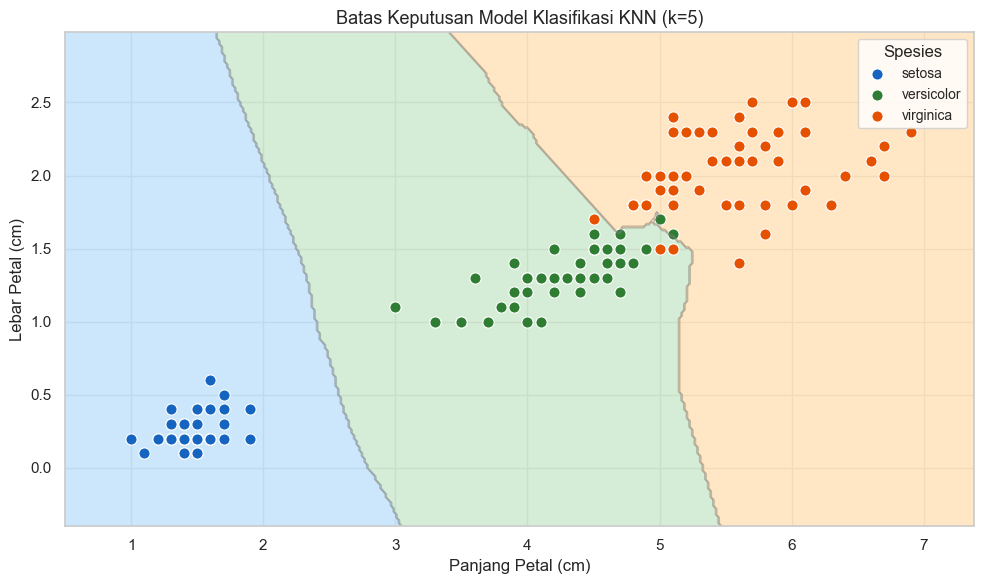

Setiap area berwarna mewakili wilayah keputusan satu kelas.
Data baru yang jatuh pada suatu area akan diklasifikasikan ke kelas area tersebut.


In [9]:
# Visualisasi batas keputusan model klasifikasi
# (disederhanakan menggunakan 2 fitur agar dapat divisualisasikan)

X2 = iris.data[:, 2:4]   # panjang dan lebar petal
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.3, random_state=42
)

model_vis = KNeighborsClassifier(n_neighbors=5)
model_vis.fit(X2_train, y2_train)

# Buat grid titik untuk mewarnai wilayah keputusan
h = 0.02
x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

warna_bg = ListedColormap(['#BBDEFB', '#C8E6C9', '#FFE0B2'])
warna_pt = ['#1565C0', '#2E7D32', '#E65100']

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=warna_bg, alpha=0.75)
plt.contour(xx, yy, Z, colors='gray', linewidths=0.5, alpha=0.5)

for i, nama in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X2[mask, 0], X2[mask, 1],
                c=warna_pt[i], label=nama, edgecolors='white', s=65, linewidths=0.8)

plt.xlabel('Panjang Petal (cm)', fontsize=12)
plt.ylabel('Lebar Petal (cm)', fontsize=12)
plt.title('Batas Keputusan Model Klasifikasi KNN (k=5)', fontsize=13)
plt.legend(title='Spesies', fontsize=10)
plt.tight_layout()
plt.show()

print("Setiap area berwarna mewakili wilayah keputusan satu kelas.")
print("Data baru yang jatuh pada suatu area akan diklasifikasikan ke kelas area tersebut.")

### 9.4.2 Regresi

**Regresi** adalah tugas memprediksi nilai kontinu (bilangan real) dari suatu input.

**Ciri utama:**
- Output berupa angka yang dapat mengambil nilai berapa pun dalam suatu rentang.
- Model mencari fungsi yang paling baik memetakan fitur X ke nilai target y.
- Berbeda dengan klasifikasi, tidak ada konsep "kelas" di sini.

**Contoh algoritma:** Regresi Linear, Ridge, Lasso, Decision Tree Regressor, Random Forest Regressor.

**Contoh permasalahan:**
- Berapa harga rumah berdasarkan luas dan lokasi?
- Berapa suhu udara besok berdasarkan data cuaca hari ini?
- Berapa pendapatan iklan bulan depan berdasarkan tren historis?

**Perbedaan mendasar dengan klasifikasi:**

| Aspek | Klasifikasi | Regresi |
|-------|------------|---------|
| Jenis output | Kategori diskrit | Angka kontinu |
| Contoh output | "Setosa", "Spam" | 350.5, 28.7°C |
| Pertanyaan | "Termasuk kelas apa?" | "Berapa nilainya?" |
| Ukuran error | Akurasi | MSE, RMSE, R² |

In [10]:
# Regresi: memprediksi tingkat perkembangan diabetes menggunakan Regresi Linear

diabetes = load_diabetes()

# Gunakan satu fitur (BMI, indeks ke-2) agar dapat divisualisasikan dengan mudah
X_reg = diabetes.data[:, 2].reshape(-1, 1)
y_reg = diabetes.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

model_reg = LinearRegression()
model_reg.fit(X_train_r, y_train_r)
y_pred_r = model_reg.predict(X_test_r)

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2   = r2_score(y_test_r, y_pred_r)

print("=== Model Regresi: Regresi Linear ===")
print(f"Dataset             : Diabetes (442 pasien)")
print(f"Jumlah data latih   : {len(X_train_r)} sampel")
print(f"Jumlah data uji     : {len(X_test_r)} sampel")
print(f"R² Score            : {r2:.4f}  (semakin mendekati 1.0, semakin baik)")
print(f"RMSE                : {rmse:.2f}  (rata-rata selisih prediksi vs nilai aktual)")

print("\nContoh prediksi (10 data pertama):")
print(f"  {'No':>3}  {'Nilai Aktual':>13}  {'Nilai Prediksi':>14}  {'Selisih':>9}")
print("  " + "-" * 46)
for i in range(10):
    selisih = abs(y_test_r[i] - y_pred_r[i])
    print(f"  {i+1:>3}  {y_test_r[i]:>13.1f}  {y_pred_r[i]:>14.1f}  {selisih:>9.1f}")

=== Model Regresi: Regresi Linear ===
Dataset             : Diabetes (442 pasien)
Jumlah data latih   : 309 sampel
Jumlah data uji     : 133 sampel
R² Score            : 0.2803  (semakin mendekati 1.0, semakin baik)
RMSE                : 62.33  (rata-rata selisih prediksi vs nilai aktual)

Contoh prediksi (10 data pertama):
   No   Nilai Aktual  Nilai Prediksi    Selisih
  ----------------------------------------------
    1          219.0           144.9       74.1
    2           70.0           187.5      117.5
    3          202.0           147.0       55.0
    4          230.0           202.4       27.6
    5          111.0           131.1       20.1
    6           84.0           126.8       42.8
    7          242.0           319.6       77.6
    8          272.0           196.0       76.0
    9           94.0            61.8       32.2
   10           96.0           166.2       70.2


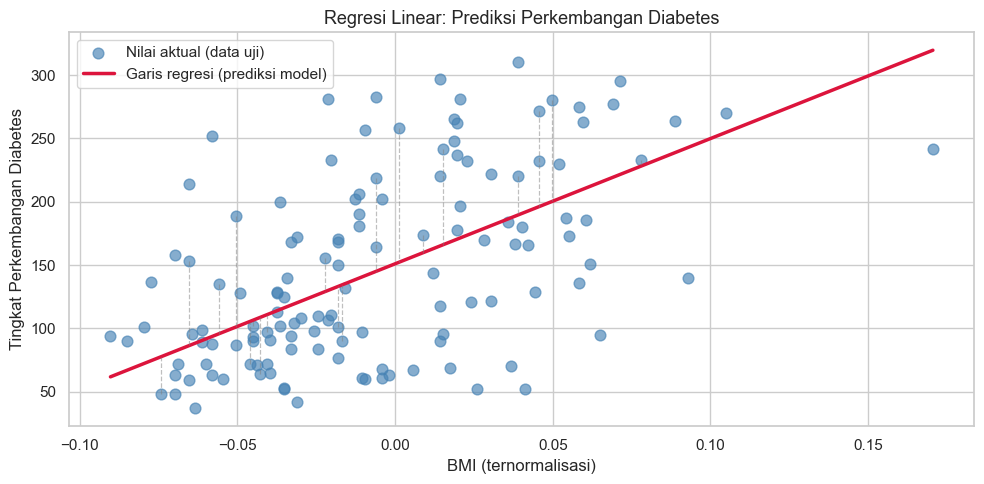

Garis putus-putus menunjukkan residual: selisih antara nilai aktual dan prediksi model.
Semakin kecil total residual, semakin baik kualitas model regresi.


In [11]:
# Visualisasi garis regresi dan residual

plt.figure(figsize=(10, 5))
plt.scatter(X_test_r, y_test_r,
            color='steelblue', alpha=0.65, s=60, label='Nilai aktual (data uji)')
plt.plot(sorted(X_test_r.flatten()), model_reg.predict(np.sort(X_test_r, axis=0)),
         color='crimson', linewidth=2.5, label='Garis regresi (prediksi model)')

# Tampilkan beberapa garis residual (selisih aktual vs prediksi)
for i in range(0, len(X_test_r), 7):
    plt.plot([X_test_r[i], X_test_r[i]], [y_test_r[i], y_pred_r[i]],
             color='gray', linewidth=0.9, linestyle='--', alpha=0.5)

plt.xlabel('BMI (ternormalisasi)', fontsize=12)
plt.ylabel('Tingkat Perkembangan Diabetes', fontsize=12)
plt.title('Regresi Linear: Prediksi Perkembangan Diabetes', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Garis putus-putus menunjukkan residual: selisih antara nilai aktual dan prediksi model.")
print("Semakin kecil total residual, semakin baik kualitas model regresi.")

---

## 9.5 Contoh Aplikasi Supervised Learning di Dunia Nyata

*Supervised learning* telah diterapkan secara luas di berbagai industri dan bidang kehidupan. Berikut adalah beberapa contoh nyata beserta implementasi kodenya.

### Gambaran Umum Bidang Penerapan

| Bidang | Contoh Penerapan | Jenis |
|--------|-----------------|-------|
| **Kesehatan** | Deteksi kanker dari gambar MRI | Klasifikasi |
| **Keuangan** | Prediksi kelayakan kredit (credit scoring) | Klasifikasi |
| **Properti** | Estimasi harga rumah | Regresi |
| **Komunikasi** | Deteksi email spam | Klasifikasi |
| **Transportasi** | Prediksi durasi perjalanan | Regresi |
| **Pemasaran** | Prediksi pelanggan yang akan berhenti berlangganan | Klasifikasi |
| **Energi** | Prediksi konsumsi listrik harian | Regresi |
| **E-commerce** | Prediksi rating ulasan dari teks | Regresi / Klasifikasi |

In [12]:
# Aplikasi 1: Prediksi Harga Rumah (Regresi)
# Simulasi dataset properti perumahan

np.random.seed(7)
n = 250
luas        = np.random.randint(36, 300, n)
kamar       = np.random.randint(1, 6, n)
jarak       = np.random.uniform(0.5, 35, n)
usia_gedung = np.random.randint(0, 45, n)

# Formula harga (disederhanakan untuk tujuan ilustrasi)
harga = (luas * 6.5 + kamar * 85 - jarak * 4.2 - usia_gedung * 2.5
         + np.random.normal(0, 70, n))
harga = np.clip(harga, 80, 4000).round(1)

df_prop = pd.DataFrame({
    'Luas_m2'              : luas,
    'Jumlah_Kamar'         : kamar,
    'Jarak_ke_Pusat_km'    : jarak.round(1),
    'Usia_Bangunan_tahun'  : usia_gedung,
    'Harga_juta_Rp'        : harga
})

print("=== Dataset Properti (10 baris pertama) ===")
print(df_prop.head(10).to_string(index=False))

X_prop = df_prop.drop('Harga_juta_Rp', axis=1)
y_prop = df_prop['Harga_juta_Rp']

X_tr, X_te, y_tr, y_te = train_test_split(X_prop, y_prop, test_size=0.2, random_state=42)
model_prop = LinearRegression()
model_prop.fit(X_tr, y_tr)

print(f"\nR² Model pada data uji : {model_prop.score(X_te, y_te):.4f}")

# Prediksi satu contoh properti baru
rumah_baru = pd.DataFrame({
    'Luas_m2': [90], 'Jumlah_Kamar': [3],
    'Jarak_ke_Pusat_km': [5.0], 'Usia_Bangunan_tahun': [5]
})
harga_pred = model_prop.predict(rumah_baru)[0]
print(f"\nPrediksi harga rumah:")
print(f"  Luas 90 m2 | 3 kamar | 5 km dari pusat | Usia 5 tahun")
print(f"  --> Rp {harga_pred:,.1f} juta")

=== Dataset Properti (10 baris pertama) ===
 Luas_m2  Jumlah_Kamar  Jarak_ke_Pusat_km  Usia_Bangunan_tahun  Harga_juta_Rp
     211             3               23.8                   21         1431.1
     232             5                9.7                    2         1834.1
      61             3               32.0                   21          294.4
     103             1                6.3                   29          667.2
     247             3               11.3                    4         1746.1
     139             5                5.2                   21         1421.3
     221             2               30.0                    7         1549.8
      59             1               30.4                   20          307.7
     108             3                6.9                   20          951.8
      78             1               26.2                   20          307.1

R² Model pada data uji : 0.9803

Prediksi harga rumah:
  Luas 90 m2 | 3 kamar | 5 km dari pusat |

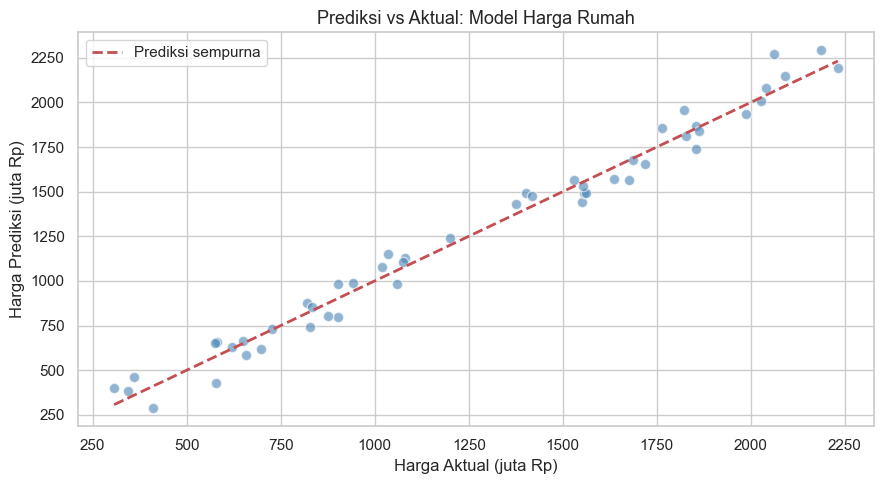

Semakin dekat titik-titik ke garis merah, semakin akurat prediksi model.


In [13]:
# Visualisasi: prediksi vs nilai aktual (model properti)

y_pred_prop = model_prop.predict(X_te)

plt.figure(figsize=(9, 5))
plt.scatter(y_te, y_pred_prop, alpha=0.6, color='steelblue', s=55, edgecolors='white')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()],
         'r--', linewidth=2, label='Prediksi sempurna')
plt.xlabel('Harga Aktual (juta Rp)', fontsize=12)
plt.ylabel('Harga Prediksi (juta Rp)', fontsize=12)
plt.title('Prediksi vs Aktual: Model Harga Rumah', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Semakin dekat titik-titik ke garis merah, semakin akurat prediksi model.")

In [14]:
# Aplikasi 2: Deteksi Spam Email (Klasifikasi Teks)

# Dataset simulasi email berlabel
email_data = [
    ("Selamat! Anda memenangkan hadiah uang tunai 100 juta. Klaim sekarang!", 1),
    ("Klik link ini untuk mendapatkan voucher gratis tanpa syarat apapun!", 1),
    ("PROMO HARI INI: diskon 90% untuk semua produk! Penawaran terbatas!", 1),
    ("Pinjaman cepat cair tanpa jaminan dan tanpa survei. Daftar sekarang!", 1),
    ("Anda terpilih menerima bantuan dana pemerintah. Hubungi kami segera!", 1),
    ("Kemenangan undian Anda senilai 50 juta sedang menunggu konfirmasi!", 1),
    ("Raih penghasilan jutaan rupiah per hari dari rumah. Info lengkap di sini!", 1),
    ("Rapat koordinasi tim dijadwalkan besok pukul 09.00 WIB di ruang A.", 0),
    ("Mohon kirimkan laporan bulanan sebelum akhir minggu ini. Terima kasih.", 0),
    ("Pengingat: batas pengumpulan tugas akhir adalah Jumat pekan depan.", 0),
    ("Undangan seminar nasional sains data akan dikirim ke email Anda.", 0),
    ("Pertemuan dengan klien dijadwalkan ulang ke Kamis pukul 14.00 WIB.", 0),
    ("Mohon konfirmasi kehadiran Anda untuk acara wisuda bulan depan.", 0),
    ("Laporan keuangan kuartal ketiga telah diunggah ke folder Drive bersama.", 0),
    ("Agenda rapat direksi akan didistribusikan melalui email resmi besok.", 0),
]

teks  = [e[0] for e in email_data]
label = [e[1] for e in email_data]

# Konversi teks ke representasi numerik (bag-of-words)
vektorizer = CountVectorizer()
X_email = vektorizer.fit_transform(teks)

model_email = MultinomialNB()
model_email.fit(X_email, label)

# Prediksi email baru yang belum pernah dilihat model
email_uji = [
    "Dapatkan hadiah jutaan rupiah dengan klik link ini sekarang juga!",
    "Mohon hadir dalam rapat koordinasi unit besok pagi.",
    "Menangkan liburan gratis ke Bali dengan mendaftar sekarang!",
    "Tolong periksa dokumen proposal sebelum presentasi Jumat depan.",
]

print("=== Deteksi Spam Email ===\n")
for email in email_uji:
    X_u   = vektorizer.transform([email])
    hasil = model_email.predict(X_u)[0]
    label_str = "SPAM" if hasil == 1 else "BUKAN SPAM"
    print(f"Email    : '{email}'")
    print(f"Prediksi : [{label_str}]")
    print()

=== Deteksi Spam Email ===

Email    : 'Dapatkan hadiah jutaan rupiah dengan klik link ini sekarang juga!'
Prediksi : [SPAM]

Email    : 'Mohon hadir dalam rapat koordinasi unit besok pagi.'
Prediksi : [BUKAN SPAM]

Email    : 'Menangkan liburan gratis ke Bali dengan mendaftar sekarang!'
Prediksi : [BUKAN SPAM]

Email    : 'Tolong periksa dokumen proposal sebelum presentasi Jumat depan.'
Prediksi : [BUKAN SPAM]



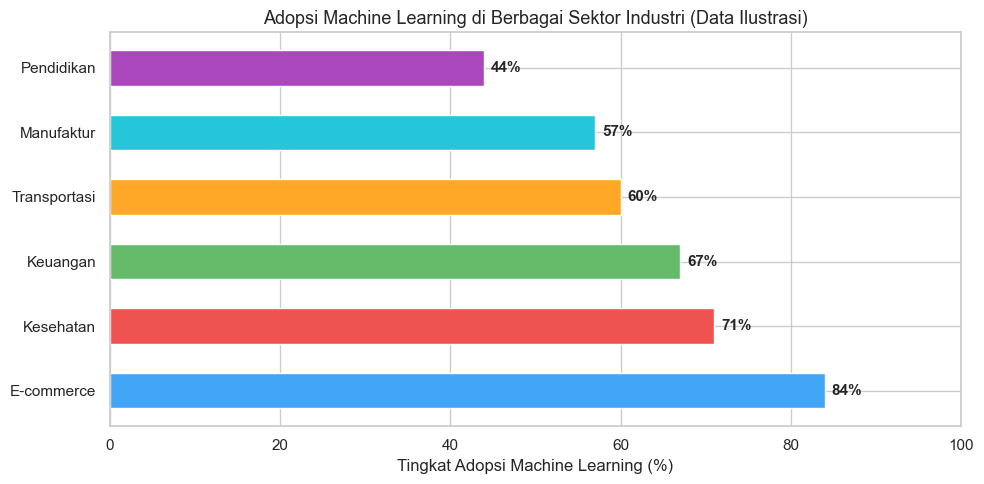

Catatan: angka di atas adalah ilustrasi untuk keperluan pembelajaran.
Penerapan ML terus berkembang pesat di hampir semua sektor industri global.


In [15]:
# Visualisasi: tingkat adopsi ML di berbagai sektor industri

bidang     = ['E-commerce', 'Kesehatan', 'Keuangan', 'Transportasi', 'Manufaktur', 'Pendidikan']
adopsi_pct = [84, 71, 67, 60, 57, 44]   # angka ilustrasi untuk tujuan pembelajaran
warna_bar  = ['#42A5F5', '#EF5350', '#66BB6A', '#FFA726', '#26C6DA', '#AB47BC']

plt.figure(figsize=(10, 5))
bars = plt.barh(bidang, adopsi_pct, color=warna_bar, edgecolor='white', height=0.55)

for bar, val in zip(bars, adopsi_pct):
    plt.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
             f'{val}%', va='center', fontsize=11, fontweight='bold')

plt.xlabel('Tingkat Adopsi Machine Learning (%)', fontsize=12)
plt.title('Adopsi Machine Learning di Berbagai Sektor Industri (Data Ilustrasi)', fontsize=13)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

print("Catatan: angka di atas adalah ilustrasi untuk keperluan pembelajaran.")
print("Penerapan ML terus berkembang pesat di hampir semua sektor industri global.")

---

## Tambahan: Alur Kerja Umum Proyek Machine Learning

Memahami alur kerja standar sangat penting sebelum mengerjakan proyek ML secara nyata. Meskipun detail setiap tahap akan dipelajari lebih mendalam pada modul-modul berikutnya, berikut adalah gambaran umumnya.

### Tahapan Alur Kerja

| Tahap | Kegiatan |
|-------|---------|
| **1. Pemahaman Masalah** | Menentukan tujuan, jenis ML yang tepat, dan metrik keberhasilan |
| **2. Pengumpulan Data** | Mengumpulkan data dari berbagai sumber yang relevan |
| **3. Eksplorasi & Praproses** | Memahami distribusi data, menangani nilai kosong, normalisasi |
| **4. Rekayasa Fitur** | Memilih, mengubah, atau menciptakan fitur yang informatif |
| **5. Pelatihan Model** | Memilih algoritma dan melatih model pada data latih |
| **6. Evaluasi Model** | Mengukur kinerja model pada data uji dengan metrik yang sesuai |
| **7. Penyebaran (Deployment)** | Mengintegrasikan model ke dalam sistem produksi |

Proses ini bersifat **iteratif**: hasil evaluasi sering mengharuskan kita kembali ke tahap sebelumnya untuk memperbaiki data, fitur, atau pilihan algoritma.

In [16]:
# Demonstrasi: seluruh alur kerja ML dalam satu blok kode yang runtut

print("=" * 58)
print("  ALUR KERJA MACHINE LEARNING: DEMONSTRASI TERPADU")
print("=" * 58)

# -- Tahap 1: Muat data --
print("\n[Tahap 1] Memuat data...")
iris = load_iris()
X, y = iris.data, iris.target
print(f"  Dataset: {X.shape[0]} sampel, {X.shape[1]} fitur, {len(np.unique(y))} kelas")

# -- Tahap 2: Eksplorasi singkat --
print("\n[Tahap 2] Eksplorasi data...")
df_exp = pd.DataFrame(X, columns=iris.feature_names)
print("  Statistik ringkas:")
for col in df_exp.columns:
    print(f"    {col:<30}: min={df_exp[col].min():.1f}, "
          f"maks={df_exp[col].max():.1f}, "
          f"rerata={df_exp[col].mean():.2f}")

# -- Tahap 3: Bagi data --
print("\n[Tahap 3] Membagi data latih dan uji (80 : 20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Data latih : {len(X_train)} sampel")
print(f"  Data uji   : {len(X_test)} sampel")

# -- Tahap 4: Latih model --
print("\n[Tahap 4] Melatih model K-Nearest Neighbors (k=5)...")
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
print("  Model berhasil dilatih.")

# -- Tahap 5: Evaluasi --
print("\n[Tahap 5] Mengevaluasi model pada data uji...")
y_pred = model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)
print(f"  Akurasi : {akurasi:.2%}")

# -- Tahap 6: Prediksi data baru --
print("\n[Tahap 6] Prediksi pada data baru (belum pernah dilihat model)...")
data_baru = np.array([
    [5.1, 3.5, 1.4, 0.2],   # kemungkinan setosa
    [6.3, 2.8, 5.1, 1.5],   # kemungkinan virginica
    [5.7, 2.9, 4.2, 1.3],   # kemungkinan versicolor
])
for sampel in data_baru:
    hasil = iris.target_names[model.predict([sampel])[0]]
    print(f"  Input {sampel}  -->  {hasil}")

print("\n[Selesai] Alur kerja ML berhasil dijalankan dari ujung ke ujung.")

  ALUR KERJA MACHINE LEARNING: DEMONSTRASI TERPADU

[Tahap 1] Memuat data...
  Dataset: 150 sampel, 4 fitur, 3 kelas

[Tahap 2] Eksplorasi data...
  Statistik ringkas:
    sepal length (cm)             : min=4.3, maks=7.9, rerata=5.84
    sepal width (cm)              : min=2.0, maks=4.4, rerata=3.06
    petal length (cm)             : min=1.0, maks=6.9, rerata=3.76
    petal width (cm)              : min=0.1, maks=2.5, rerata=1.20

[Tahap 3] Membagi data latih dan uji (80 : 20)...
  Data latih : 120 sampel
  Data uji   : 30 sampel

[Tahap 4] Melatih model K-Nearest Neighbors (k=5)...
  Model berhasil dilatih.

[Tahap 5] Mengevaluasi model pada data uji...
  Akurasi : 100.00%

[Tahap 6] Prediksi pada data baru (belum pernah dilihat model)...
  Input [5.1 3.5 1.4 0.2]  -->  setosa
  Input [6.3 2.8 5.1 1.5]  -->  virginica
  Input [5.7 2.9 4.2 1.3]  -->  versicolor

[Selesai] Alur kerja ML berhasil dijalankan dari ujung ke ujung.


---

## Ringkasan Modul 9

Pada modul ini, kita telah mempelajari fondasi konseptual dan praktis dari *machine learning*:

**9.1 Definisi Machine Learning**  
ML adalah kemampuan komputer untuk belajar dari data secara otomatis tanpa diprogram secara eksplisit untuk setiap tugas. Komponennya meliputi data, fitur, label, model, dan algoritma.

**9.2 Perbedaan ML dengan Pemrograman Konvensional**  
Pemrograman konvensional mensyaratkan aturan manual dari programmer. ML membalik paradigma ini: aturan ditemukan secara otomatis oleh algoritma berdasarkan data berlabel.

**9.3 Mengapa ML Dibutuhkan**  
Volume data yang masif, kompleksitas pola, dan kebutuhan adaptasi menjadikan ML pendekatan yang tak tergantikan dalam sains data modern.

**Anatomi Dataset ML**  
Setiap dataset terdiri dari fitur (X) sebagai kolom input dan label (y) sebagai kolom output yang ingin diprediksi oleh model.

**9.4 Supervised Learning**  
- **Klasifikasi**: memprediksi kelas diskrit. Contoh: spesies bunga, spam/bukan spam.  
- **Regresi**: memprediksi nilai kontinu. Contoh: harga rumah, tingkat perkembangan penyakit.

**9.5 Aplikasi Supervised Learning**  
ML diterapkan luas di bidang kesehatan, keuangan, properti, komunikasi digital, dan banyak sektor lainnya.

**Alur Kerja Proyek ML**  
Proyek ML mengikuti alur sistematis yang iteratif: pemahaman masalah, pengumpulan data, eksplorasi, pelatihan, evaluasi, dan penyebaran.

---

**Pratinjau Pertemuan Berikutnya:**  
Pada dua pertemuan berikutnya, kita akan mempelajari *unsupervised learning* (clustering dan reduksi dimensi), konsep dasar *reinforcement learning*, konsep pembagian data latih-uji, cara model "belajar", serta fenomena *overfitting* dan *underfitting*.